Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn import metrics

Data Collection & Analysis

In [2]:
insurance_dataset = pd.read_csv("insurance.csv")

In [3]:
# first 5 rows of the dataframe
insurance_dataset.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# number of rows and columns
insurance_dataset.shape

(1338, 7)

In [5]:
# getting some informations about the dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Categorical Features:
- Sex
- Smoker
- Region

In [6]:
# checking for missing values
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data Analysis

In [7]:
# statistical Measures of the dataset
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


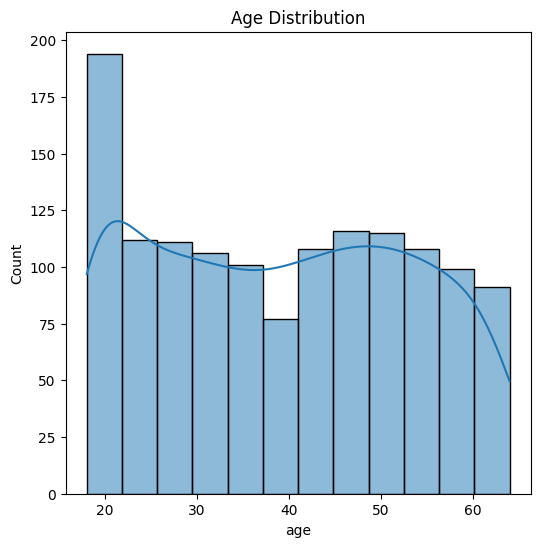

In [8]:
# distribution of age value
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['age'], kde=True)
plt.title('Age Distribution')
plt.show()


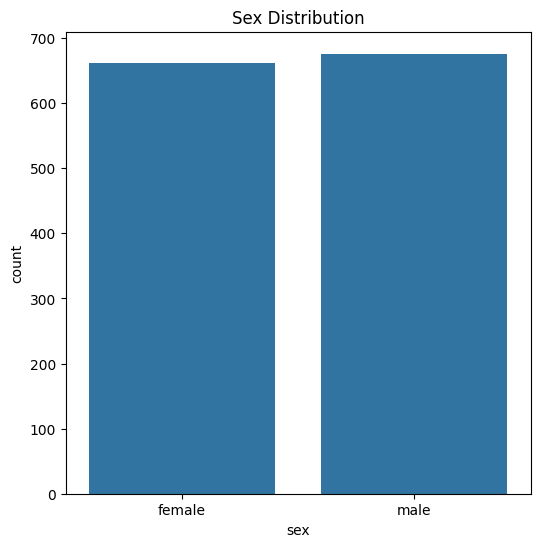

sex
male      676
female    662
Name: count, dtype: int64

In [9]:
plt.figure(figsize=(6,6))
sns.countplot(x='sex', data=insurance_dataset)
plt.title('Sex Distribution')
plt.show()

insurance_dataset['sex'].value_counts()

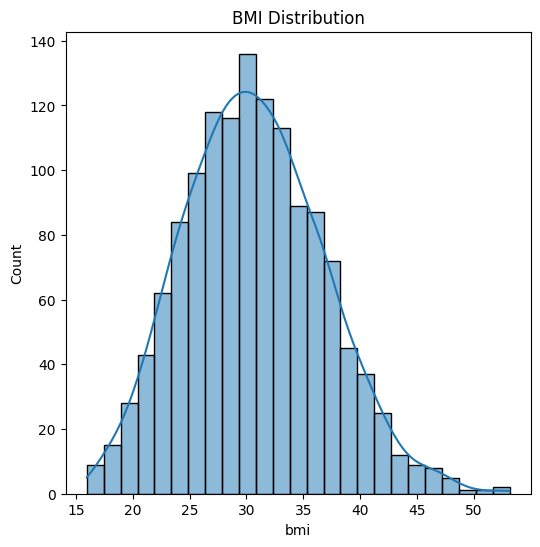

In [10]:
# bmi distribution
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['bmi'], kde=True)
plt.title('BMI Distribution')
plt.show()

Normal BMI Range --> 18.5 to 24.9

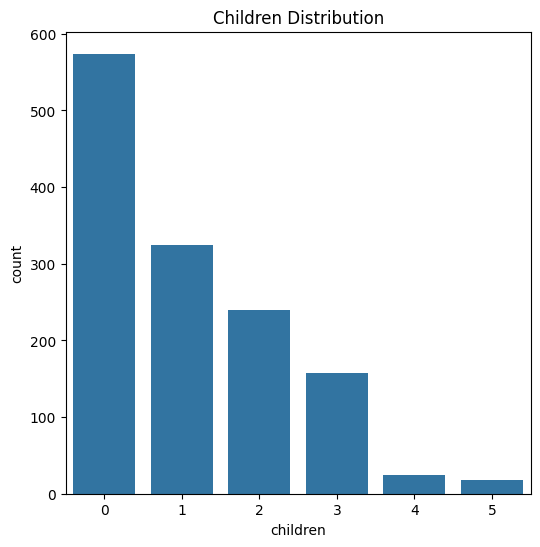

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [11]:
# children column
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=insurance_dataset)
plt.title('Children Distribution')
plt.show()

insurance_dataset['children'].value_counts()

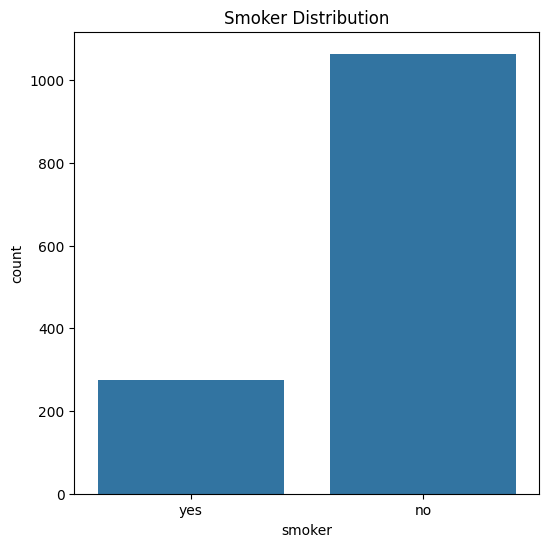

smoker
no     1064
yes     274
Name: count, dtype: int64

In [12]:
# smoker column
plt.figure(figsize=(6,6))
sns.countplot(x='smoker', data=insurance_dataset)
plt.title('Smoker Distribution')
plt.show()

insurance_dataset['smoker'].value_counts()

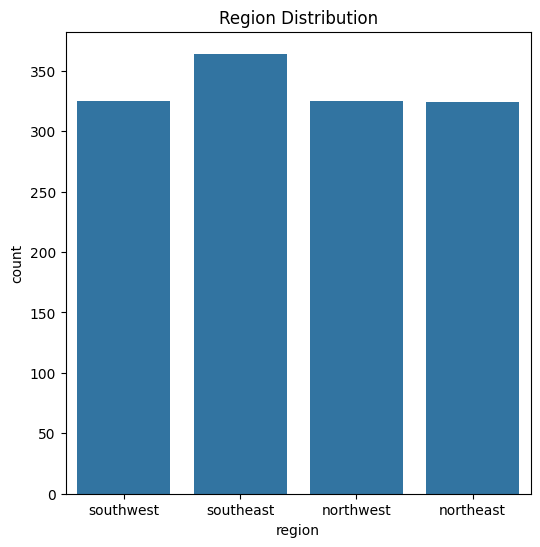

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [13]:
# region column
plt.figure(figsize=(6,6))
sns.countplot(x='region', data=insurance_dataset)
plt.title('Region Distribution')
plt.show()

insurance_dataset['region'].value_counts()

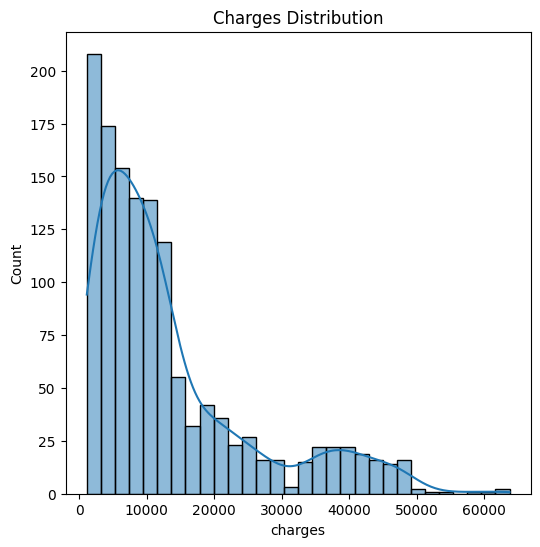

In [14]:
# distribution of charges value
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['charges'], kde=True)
plt.title('Charges Distribution')
plt.show()

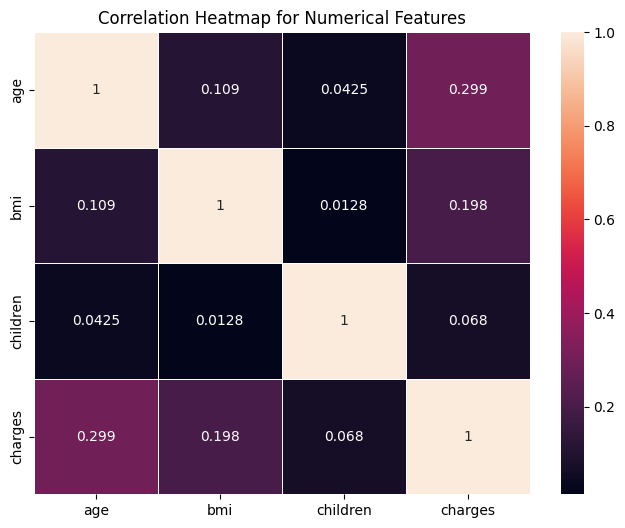

In [15]:
numerical_columns = insurance_dataset[['age', 'bmi', 'children', 'charges']]

plt.figure(figsize=(8, 6))

correlation_numeric = numerical_columns.corr()

sns.heatmap(
    correlation_numeric,
    annot=True,
    cmap='rocket',
    fmt='.3g',
    linewidths=0.5
)

plt.title('Correlation Heatmap for Numerical Features')
plt.show()

Data Pre-Processing

# **Encoding the categorical features**

In [16]:
# encoding sex column
insurance_dataset.replace({'sex': {'male': 0, 'female': 1}}, inplace=True)

3 # encoding 'smoker' column

insurance_dataset.replace({'smoker': {'yes': 0, 'no': 1}}, inplace=True)
# encoding 'region' column
insurance_dataset.replace({
    'region': {
        'southeast': 0,
        'southwest': 1,
        'northeast': 2,
        'northwest': 3
    }
}, inplace=True)

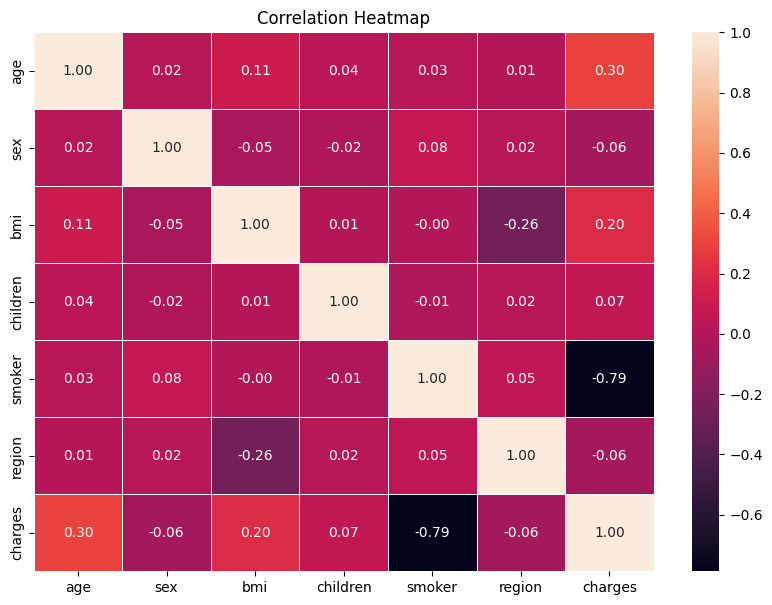

In [17]:
plt.figure(figsize=(10, 7))

correlation = insurance_dataset.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='rocket',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

# **Splitting the Features and Target**

In [18]:
X = insurance_dataset.drop(columns='charges', axis=1)
Y = insurance_dataset['charges']

# **Splitting the data into Training data & Testing Data**

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

In [20]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


In [21]:
from sklearn.metrics import mean_squared_error

def display_results(model):
    coefs = [model.intercept_]
    coefs += list(model.coef_)
    ytrain_predict = model.predict(X_train)
    ytest_predict = model.predict(X_test)

    train_error = metrics.r2_score(Y_train, ytrain_predict)
    test_error = metrics.r2_score(Y_test, ytest_predict)

    print("Training error (r2):", train_error)
    print("Testing error (r2):", test_error)

    # Scatter plot for training and testing predictions
    plt.scatter(Y_train, ytrain_predict, marker='o', label='Train Predictions')
    plt.scatter(Y_test, ytest_predict, marker='^', label='Test Predictions')

    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title('True vs Predicted Values')
    plt.legend()
    plt.show()

    print("Coefficients:")
    print(coefs)

# **Model Training**

Linear Regression

In [22]:
# loading the Linear Regression model
regressor = LinearRegression()

regressor.fit(X_train, Y_train)

LinearRegression()

Model Evaluation

Training error (r2): 0.751505643411174
Testing error (r2): 0.7447273869684077


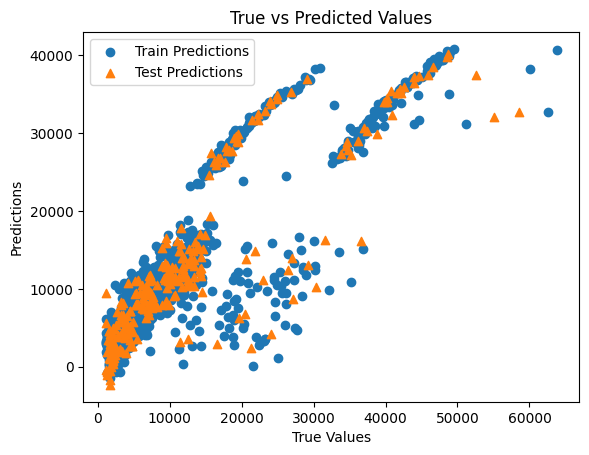

Coefficients:
[11357.66874254093, 251.40512195917304, 26.117159659125623, 330.6463715684861, 580.2743829604742, -23928.101710611194, 212.2224272833257]


In [23]:
display_results(regressor)

In [24]:
# loading the linear regression model _ lasso
lass_reg_model = Lasso()

lass_reg_model.fit(X_train, Y_train)

Lasso()

Training error (r2): 0.7515055550686265
Testing error (r2): 0.7447245444913575


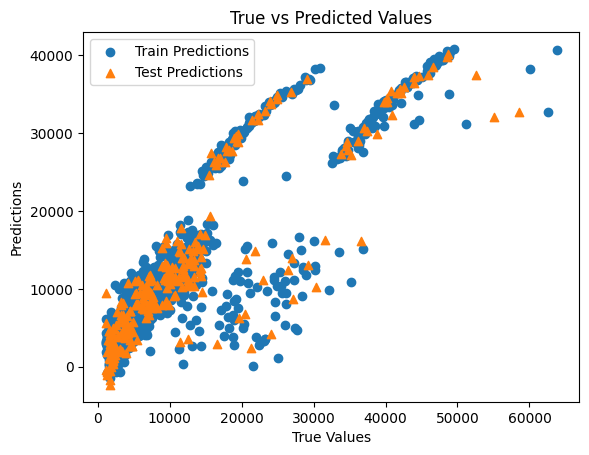

Coefficients:
[11360.150526831641, 251.40215241660243, 21.65926528061186, 330.5402196946989, 579.6270691980636, -23921.47174019678, 211.20817809459018]


In [25]:
display_results(lass_reg_model)

In [27]:
rid_reg_model = Ridge()

rid_reg_model.fit(X_train, Y_train)

Ridge()

Training error (r2): 0.7514846144151407
Testing error (r2): 0.7448008334274916


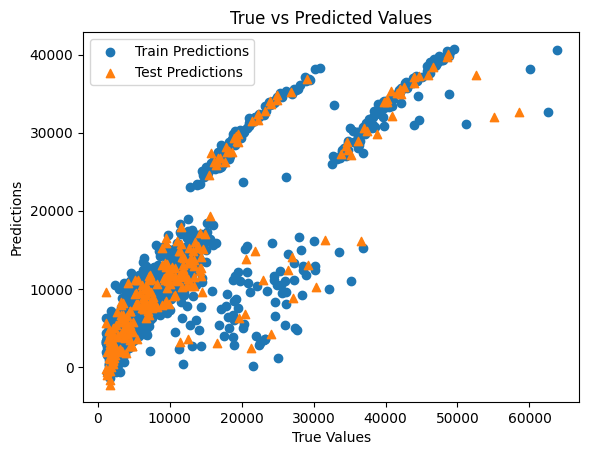

Coefficients:
[11264.387906524626, 251.30967349091327, 18.502976994096354, 330.4840655730794, 580.41830563793, -23790.444428624625, 209.54385018736065]


In [28]:
display_results(rid_reg_model)

Building a Predictive System

In [29]:
input_data = (31,1,25.74,0,1,0) # NEW DATA

# changing input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = regressor.predict(input_data_reshaped)
print(prediction)

print('The insurance cost is USD ', prediction[0])

[3760.0805765]
The insurance cost is USD  3760.0805764960587


c:\Users\LapTop\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
